In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
import seaborn as sns
from mlxtend.plotting import plot_decision_regions

In [2]:
X,y= make_moons(100,noise=0.25,random_state=42)

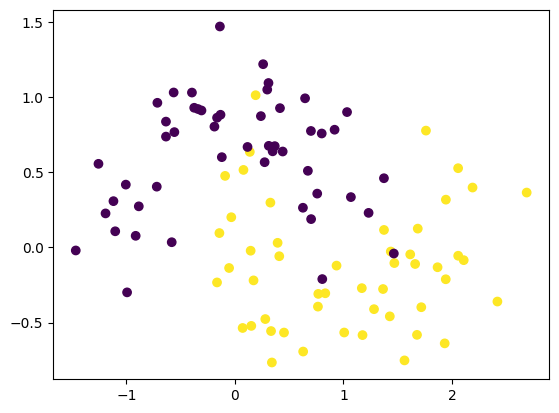

In [3]:
import matplotlib.pyplot as plt
plt.scatter(X[:,0], X[:,1], c=y)
plt.show()

In [4]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout
from tensorflow.keras.optimizers import Adam

In [5]:
model = Sequential()

model.add(Dense(2,activation='relu',input_dim=2))
model.add(Dense(1,activation='sigmoid'))

model.summary()


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 2)                 6         
                                                                 
 dense_1 (Dense)             (None, 1)                 3         
                                                                 
Total params: 9 (36.00 Byte)
Trainable params: 9 (36.00 Byte)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [7]:
model.get_weights()

[array([[-0.8413338 , -1.1038841 ],
        [-0.83857876, -0.6863106 ]], dtype=float32),
 array([0., 0.], dtype=float32),
 array([[-0.7190606],
        [ 1.2376224]], dtype=float32),
 array([0.], dtype=float32)]

In [8]:
initial_weights = model.get_weights()

In [9]:
initial_weights[0] = np.zeros(model.get_weights()[0].shape)
initial_weights[1] = np.zeros(model.get_weights()[1].shape)
initial_weights[2] = np.zeros(model.get_weights()[2].shape)
initial_weights[3] = np.zeros(model.get_weights()[3].shape)

In [10]:
model.set_weights(initial_weights)

In [11]:
model.get_weights()

[array([[0., 0.],
        [0., 0.]], dtype=float32),
 array([0., 0.], dtype=float32),
 array([[0.],
        [0.]], dtype=float32),
 array([0.], dtype=float32)]

In [12]:
model.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])

In [13]:
history = model.fit(X,y,epochs=100,validation_split=0.2)

Epoch 1/100


3/3 [==============================] - 2s 124ms/step - loss: 0.6932 - accuracy: 0.4500 - val_loss: 0.6931 - val_accuracy: 0.6000
Epoch 2/100
3/3 [==============================] - 0s 24ms/step - loss: 0.6931 - accuracy: 0.5000 - val_loss: 0.6933 - val_accuracy: 0.4000
Epoch 3/100
3/3 [==============================] - 0s 26ms/step - loss: 0.6931 - accuracy: 0.5250 - val_loss: 0.6935 - val_accuracy: 0.4000
Epoch 4/100
3/3 [==============================] - 0s 30ms/step - loss: 0.6930 - accuracy: 0.5250 - val_loss: 0.6936 - val_accuracy: 0.4000
Epoch 5/100
3/3 [==============================] - 0s 25ms/step - loss: 0.6930 - accuracy: 0.5250 - val_loss: 0.6938 - val_accuracy: 0.4000
Epoch 6/100
3/3 [==============================] - 0s 30ms/step - loss: 0.6930 - accuracy: 0.5250 - val_loss: 0.6940 - val_accuracy: 0.4000
Epoch 7/100
3/3 [==============================] - 0s 34ms/step - loss: 0.6929 - accuracy: 0.5250 - val_loss: 0.6941 - val_accuracy: 0.4000
Epoch 8/100
3/3 [

In [14]:
model.get_weights()

[array([[0., 0.],
        [0., 0.]], dtype=float32),
 array([0., 0.], dtype=float32),
 array([[0.],
        [0.]], dtype=float32),
 array([-0.06010095], dtype=float32)]

9600/9600 [==============================] - 34s 3ms/step


<Axes: >

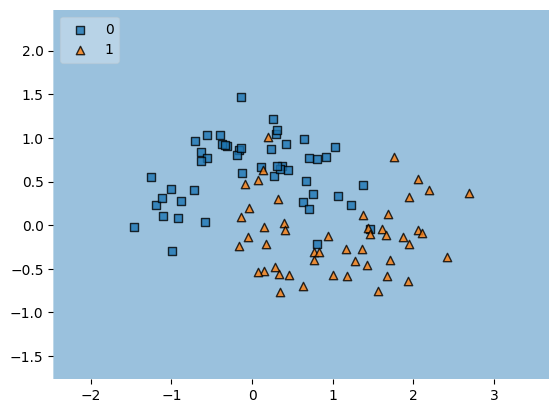

In [15]:
plot_decision_regions(X,y.astype('int'), clf=model, legend=2)